# 🏦 Bank Customer Churn Prediction Using ANN

<h2>Import Libraries</h2>

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load Dataset


In [48]:
data = pd.read_csv("Churn_Modelling.csv")

data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#  Understand Dataset

In [49]:
data.shape

(10000, 14)

In [50]:
data.size

140000

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [52]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [53]:
data = data.drop_duplicates()

In [54]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# EDA

* These description says "0" means stayed and "1" means left 

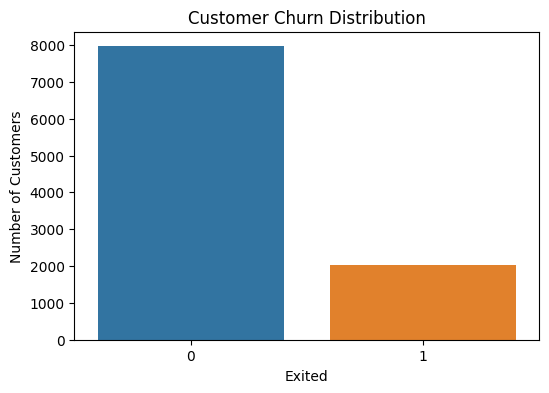

In [55]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Exited", data=data)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

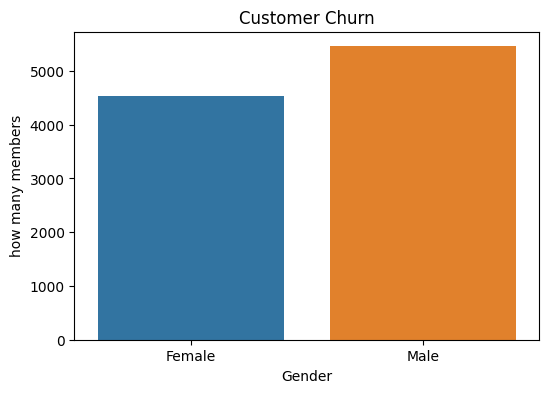

In [56]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Gender", data=data)

plt.title("Customer Churn")
plt.xlabel("Gender")
plt.ylabel("how many members")

plt.show()

* "I used boxplots to identify possible outliers in numerical features such as Age, Balance, Credit Score and Estimated Salary. I checked the outliers before deciding whether they need treatment."

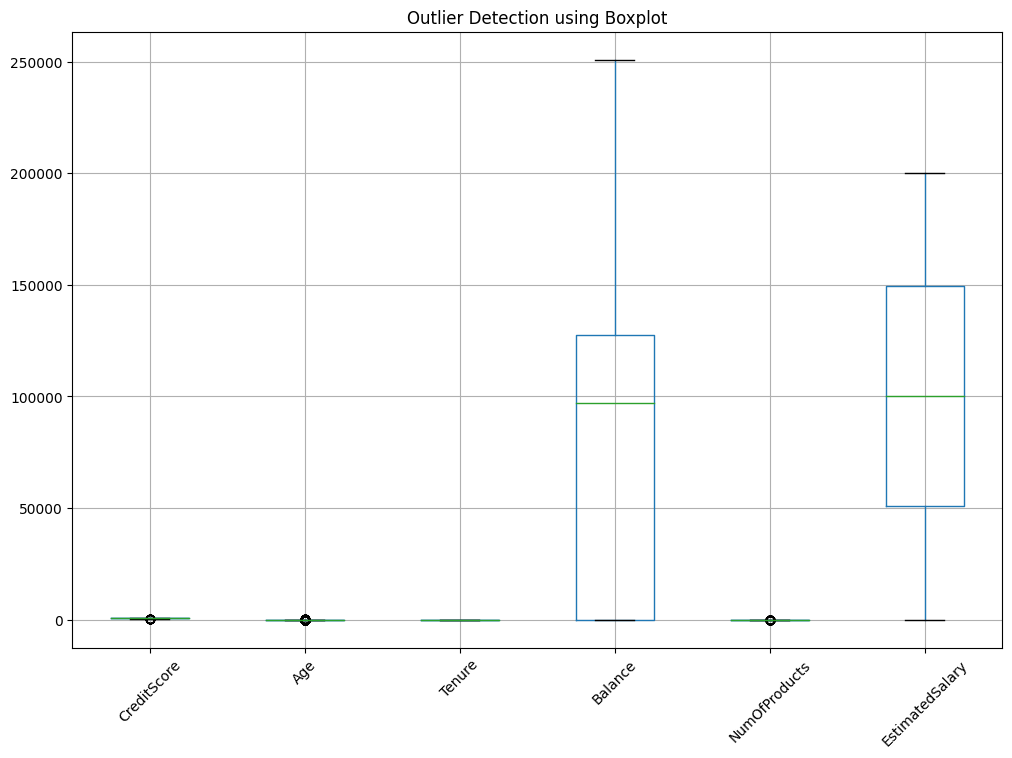

In [57]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

plt.figure(figsize=(12, 8))

data[numeric_columns].boxplot()

plt.title("Outlier Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

In [60]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for column in numeric_columns:
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data = data[
        (data[column] >= lower_bound) &
        (data[column] <= upper_bound)
    ]

print("Shape after removing outliers:", data.shape)

Shape after removing outliers: (9342, 14)


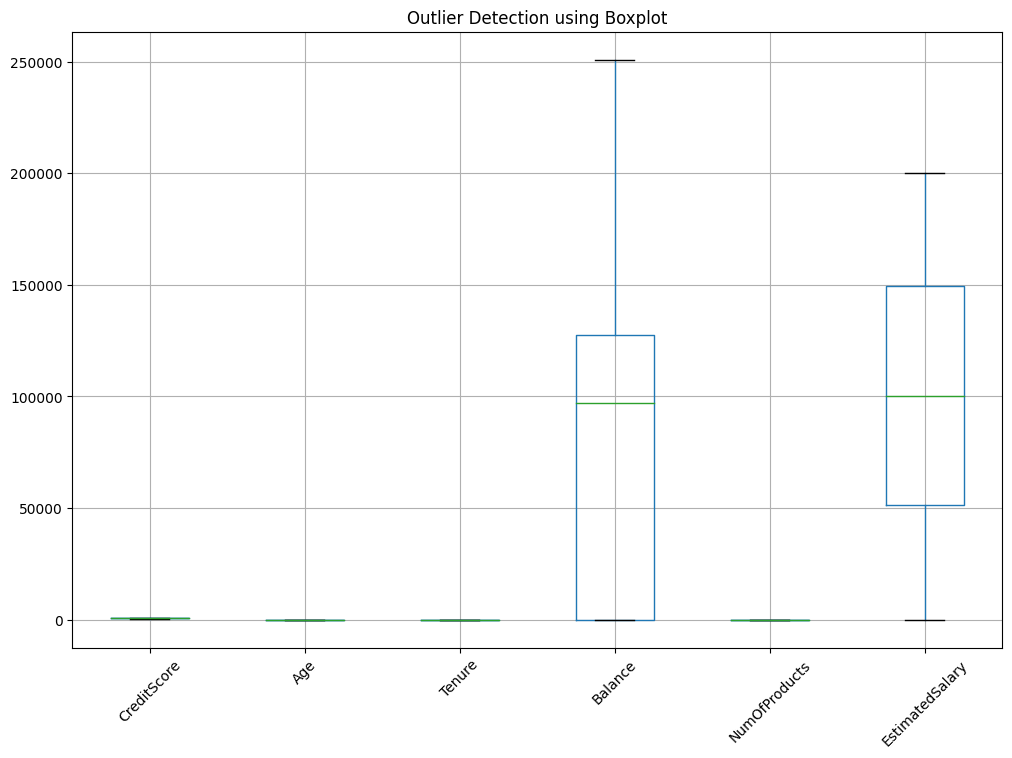

In [61]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

plt.figure(figsize=(12, 8))

data[numeric_columns].boxplot()

plt.title("Outlier Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

* “Here, I use boxplots to detect outliers in all numerical columns. Each boxplot shows the distribution of one feature, and the points outside the whiskers represent possible outliers.”

* “I used a for loop to create separate boxplots for each numerical column and identify outliers easily.”

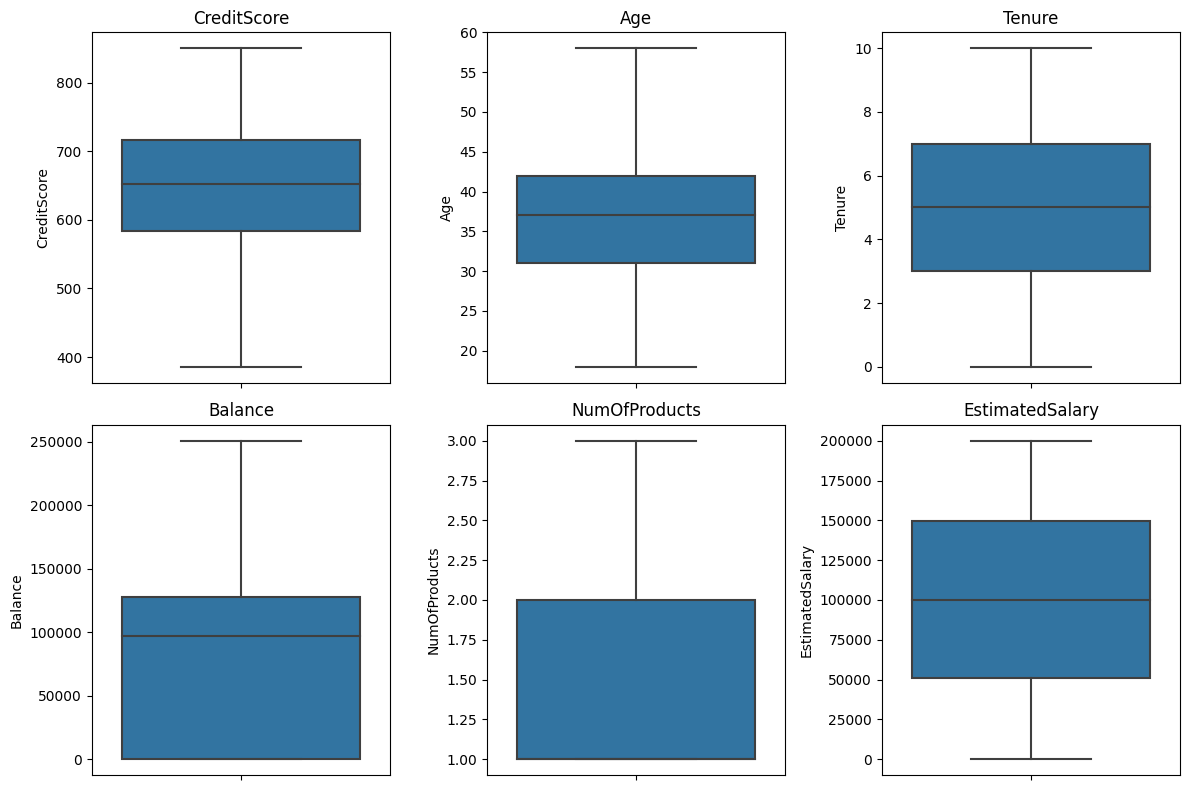

In [62]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

plt.figure(figsize=(12, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [64]:
data = data.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

In [65]:
data = pd.get_dummies(
    data,
    columns=["Geography", "Gender"],
    drop_first=True
)

In [66]:
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [67]:
X = data.drop("Exited", axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [68]:
y = data["Exited"]
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Architecture:
* Input Layer
 *    ↓
* 16 Neurons - ReLU
 *    ↓
* 8 Neurons - ReLU
*    ↓
* 1 Neuron - Sigmoid

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(16, activation="relu"),

    Dense(8, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [72]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [73]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
187/187 [==============================] - 2s 5ms/step - loss: 0.5475 - accuracy: 0.7459 - val_loss: 0.4581 - val_accuracy: 0.8094
Epoch 2/50
187/187 [==============================] - 1s 3ms/step - loss: 0.4371 - accuracy: 0.8128 - val_loss: 0.4215 - val_accuracy: 0.8201
Epoch 3/50
187/187 [==============================] - 1s 3ms/step - loss: 0.4113 - accuracy: 0.8252 - val_loss: 0.4054 - val_accuracy: 0.8321
Epoch 4/50
187/187 [==============================] - 1s 3ms/step - loss: 0.3975 - accuracy: 0.8344 - val_loss: 0.3965 - val_accuracy: 0.8314
Epoch 5/50
187/187 [==============================] - 1s 3ms/step - loss: 0.3875 - accuracy: 0.8389 - val_loss: 0.3889 - val_accuracy: 0.8234
Epoch 6/50
187/187 [==============================] - 1s 3ms/step - loss: 0.3786 - accuracy: 0.8436 - val_loss: 0.3813 - val_accuracy: 0.8308
Epoch 7/50
187/187 [==============================] - 1s 3ms/step - loss: 0.3701 - accuracy: 0.8464 - val_loss: 0.3752 - val_accuracy: 0.8301
Epoch 

In [74]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

59/59 [==============================] - 0s 2ms/step - loss: 0.3450 - accuracy: 0.8582
Test Accuracy: 0.858212947845459


In [75]:
y_probability = model.predict(X_test)

y_pred = (y_probability > 0.5).astype(int)

59/59 [==============================] - 0s 2ms/step


[[1446   65]
 [ 200  158]]


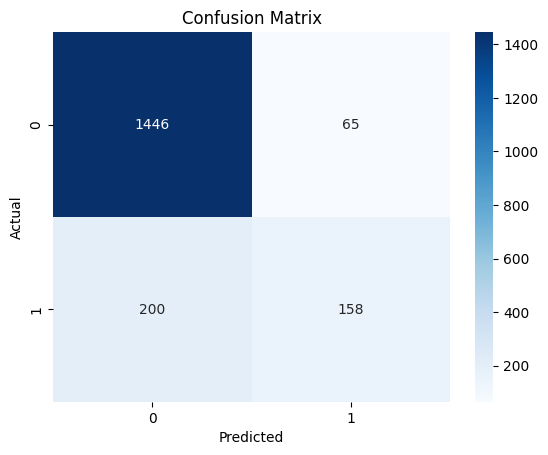

In [76]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report


In [77]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1511
           1       0.71      0.44      0.54       358

    accuracy                           0.86      1869
   macro avg       0.79      0.70      0.73      1869
weighted avg       0.85      0.86      0.84      1869



# Training Accuracy Graph

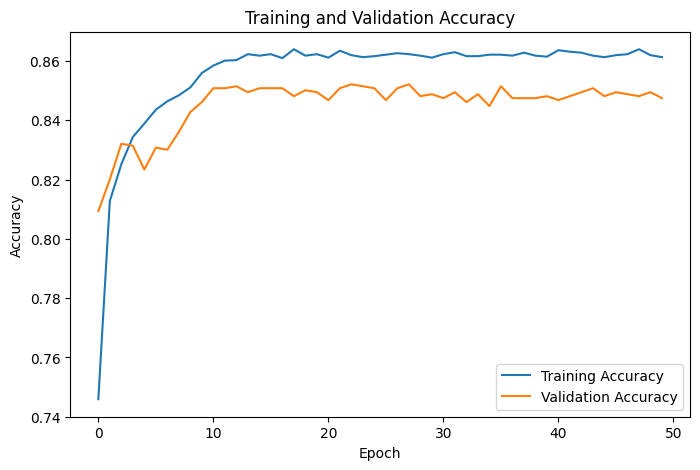

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Loss Graph

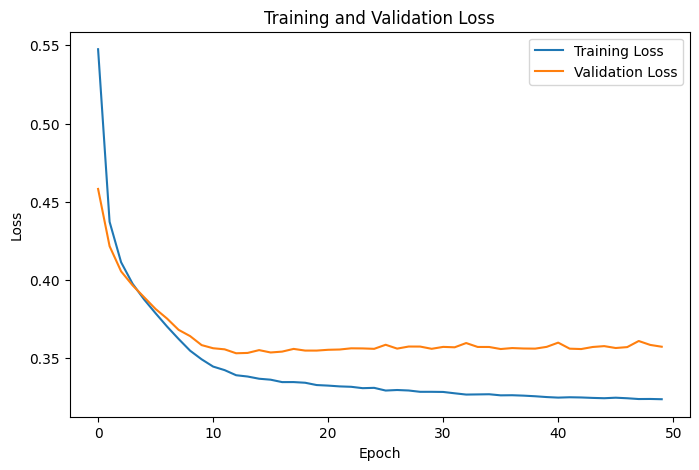

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [81]:
model.save("bank_churn_ann.h5")

In [80]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [82]:
import json

feature_names = X.columns.tolist()

with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("Feature names saved successfully!")

Feature names saved successfully!
